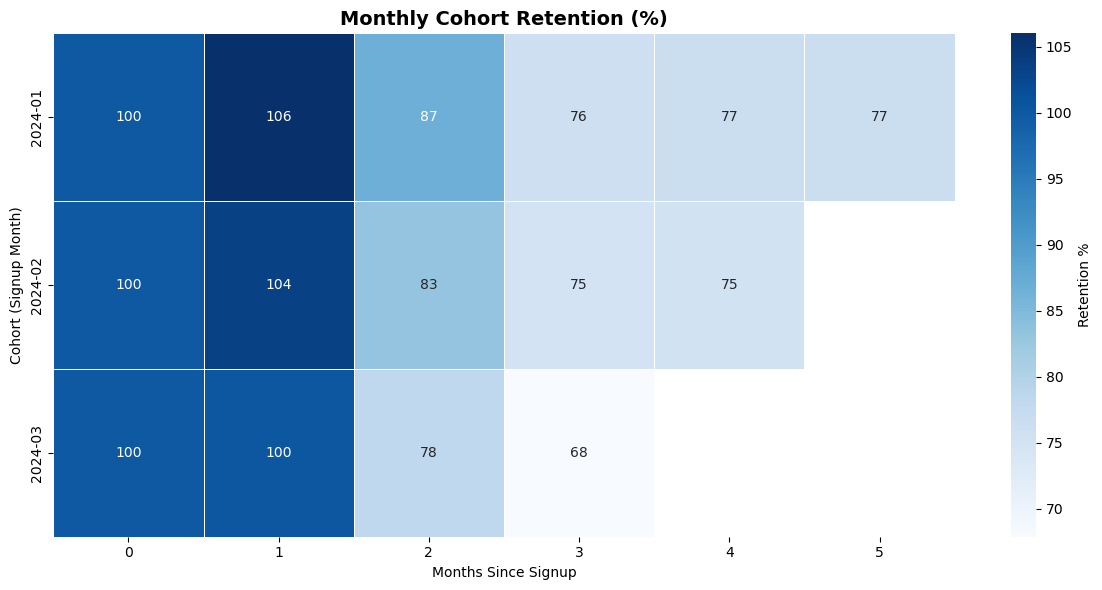

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\Soumili Nag\OneDrive\Desktop\projects\SaaS Product Analytics\data\saas_events.csv', parse_dates=['event_date', 'signup_date'])

# Cohort = month of signup
df['cohort_month'] = df['signup_date'].dt.to_period('M')
df['activity_month'] = df['event_date'].dt.to_period('M')

# Months since signup
df['months_since_signup'] = (
    df['activity_month'] - df['cohort_month']
).apply(lambda x: x.n)

# Count unique users per cohort per period
cohort_data = (df.groupby(['cohort_month', 'months_since_signup'])['user_id']
               .nunique()
               .reset_index())

cohort_pivot = cohort_data.pivot_table(
    index='cohort_month',
    columns='months_since_signup',
    values='user_id'
)

# Retention % relative to Month 0
cohort_size  = cohort_pivot[0]
retention_df = cohort_pivot.divide(cohort_size, axis=0).round(3) * 100

# --- Plot Heatmap ---
fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    retention_df,
    annot=True, fmt='.0f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': 'Retention %'}
)
ax.set_title('Monthly Cohort Retention (%)', fontsize=14, fontweight='bold')
ax.set_xlabel('Months Since Signup')
ax.set_ylabel('Cohort (Signup Month)')
plt.tight_layout()
plt.savefig(r'C:\Users\Soumili Nag\OneDrive\Desktop\projects\SaaS Product Analytics\images\cohort_retention.png', dpi=150)
plt.show()